📊 Modeling Guide – Where to Start

🎯 1. Problem Summary
- Task: Binary classification
- Target: oks_target_variable (whether patient improvement > 7 points)
- Class Imbalance: ~5:1 ratio (majority class dominates)
- Data: Fully preprocessed, no missing values, ready for modeling

🔧 2. Handling Class Imbalance
- You have several options:
✅ Option A: Class Weights (Recommended first approach)

- Use class_weight='balanced' in your classifier
- No need to modify data
- Works with: LogisticRegression, RandomForest, XGBoost, etc.

✅ Option B: Resampling (SMOTE)

- Apply SMOTE only to training data inside cross-validation
- Use imblearn.pipeline.Pipeline to prevent data leakage
- Best for smaller datasets

✅ Option C: Threshold Tuning

- Train normally, then adjust decision threshold
- Optimize for your preferred metric (F1, recall, precision)


📈 3. Evaluation Metrics
Given class imbalance, DO NOT rely solely on accuracy. Focus on:
Primary Metrics

- F1-Score (balance between precision and recall)
- ROC-AUC (overall discrimination ability)
- Precision-Recall AUC (better for imbalanced data)

Secondary Metrics

- Recall (if you want to catch all positive cases)
- Precision (if false positives are costly)
- Confusion Matrix (understand errors)


🧪 4. Model Selection Strategy
Baseline Models (Start here)

- Logistic Regression (class_weight='balanced')
- Random Forest (class_weight='balanced')
- Dummy Classifier (minimum performance)

Advanced Models (After baseline)

- XGBoost or LightGBM (handle categorical features well)
- CatBoost (native categorical support)
- Ensemble methods (stacking, voting)


🔄 5. Cross-Validation Strategy

- Use StratifiedKFold (5–10 folds)
- Maintains class distribution in each fold
- Report mean ± std of metrics

Important:

- If using SMOTE, apply it inside each CV fold
- Use imblearn.pipeline.Pipeline to prevent leakage


🎛️ 6. Hyperparameter Tuning
- Step 1: Train baseline models with default parameters
- Step 2: Use GridSearchCV or RandomizedSearchCV
- Step 3: Focus on models that performed best in baseline
Key Parameters to Tune
Random Forest
- Plain Textn_estimators: [100, 200, 500]max_depth: [10, 20, None]min_samples_split: [2, 5, 10]class_weight: ['balanced']Show more lines
XGBoost
- Plain Textn_estimators: [100, 200, 500]learning_rate: [0.01, 0.1, 0.3]max_depth: [3, 5, 7]scale_pos_weight: [calculated from class ratio]Show more lines

📊 7. Feature Engineering (Optional)

Feature Interactions:
- Example: age_band * heart_disease
Feature Selection:
- Use feature importance from tree-based models
- Try Recursive Feature Elimination (RFE)
Categorical Encoding:

- One-Hot Encoding for low-cardinality features
- Target Encoding for high-cardinality features (e.g., provider_code)

⚠️ 8. Important Reminders
- ✅ Use stratified cross-validation
- ✅ Focus on F1/ROC-AUC, not just accuracy
- ✅ Handle class imbalance (class weights or SMOTE)
- ✅ Evaluate on test set ONLY ONCE at the end
- ✅ Save your best model with joblib
- ❌ Touch the test set during model development
- ❌ Use SMOTE before train-test split
- ❌ Rely on accuracy alone for imbalanced data
- ❌ Forget to set random_state for reproducibility
- ❌ Oversample test data

# Encoded data

In [19]:
# Load encoded data

X_train_final_encoded = pd.read_parquet('../data/cleaned/X_train_encoded_wo_provider.parquet')
y_train = pd.read_parquet('../data/cleaned/y_train.parquet').squeeze()
print("✓ Encoded data loaded successfully")

✓ Encoded data loaded successfully


In [20]:
X_train_final_encoded.head(5)

,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,t0_disability,heart_disease,high_bp,stroke,circulation,...,t0_living_arrangements_2.0,t0_living_arrangements_4.0,Region_East of England,Region_London,Region_North East,Region_North West,Region_South East,Region_South West,Region_West Midlands,Region_Yorkshire and The Humber
0,0.0,0.0,0,2.0,0.0,0.0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0,2.0,0.0,0.0,0,0,0,0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0,3.0,0.0,1.0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0,2.0,0.0,0.0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0,2.0,0.0,0.0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [21]:
X_train_final_encoded.columns.tolist()

['gender',
 't0_assisted',
 't0_assisted_by',
 't0_symptom_period',
 't0_previous_surgery',
 't0_disability',
 'heart_disease',
 'high_bp',
 'stroke',
 'circulation',
 'lung_disease',
 'diabetes',
 'kidney_disease',
 'nervous_system',
 'liver_disease',
 'cancer',
 'depression',
 'arthritis',
 't0_mobility',
 't0_self_care',
 't0_activity',
 't0_discomfort',
 't0_anxiety',
 'oks_t0_pain',
 'oks_t0_night_pain',
 'oks_t0_washing',
 'oks_t0_transport',
 'oks_t0_walking',
 'oks_t0_standing',
 'oks_t0_limping',
 'oks_t0_kneeling',
 'oks_t0_work',
 'oks_t0_confidence',
 'oks_t0_shopping',
 'oks_t0_stairs',
 'oks_t0_score',
 'University Hospital',
 'independent_hospital',
 'comorbidity_count',
 'oks_pain_subscale',
 'oks_function_subscale',
 'oks_adl_subscale',
 'year_2017/18',
 'year_2018/19',
 'age_band_3',
 'age_band_4',
 'age_band_5',
 't0_living_arrangements_2.0',
 't0_living_arrangements_4.0',
 'Region_East of England',
 'Region_London',
 'Region_North East',
 'Region_North West',
 'Regi

Correlation matrix shape: (57, 57)

Highest correlations with each variable (top 5):

gender:
  oks_t0_kneeling: 0.338
  oks_t0_shopping: 0.192
  oks_t0_score: 0.190
  oks_function_subscale: 0.176
  oks_adl_subscale: 0.171

t0_assisted:
  t0_self_care: 0.173
  age_band_5: 0.173
  t0_disability: 0.136
  t0_discomfort: 0.124
  t0_anxiety: 0.119

t0_assisted_by:
  gender: nan
  t0_assisted: nan
  t0_symptom_period: nan
  t0_previous_surgery: nan
  t0_disability: nan

t0_symptom_period:
  age_band_3: 0.090
  gender: 0.080
  arthritis: 0.060
  t0_disability: 0.034
  comorbidity_count: 0.027

t0_previous_surgery:
  circulation: 0.032
  independent_hospital: 0.024
  oks_t0_limping: 0.024
  Region_London: 0.018
  year_2017/18: 0.016

t0_disability:
  t0_self_care: 0.302
  t0_activity: 0.241
  t0_discomfort: 0.240
  t0_anxiety: 0.223
  t0_mobility: 0.199

heart_disease:
  comorbidity_count: 0.344
  circulation: 0.096
  gender: 0.086
  high_bp: 0.080
  stroke: 0.075

high_bp:
  comorbidity_count

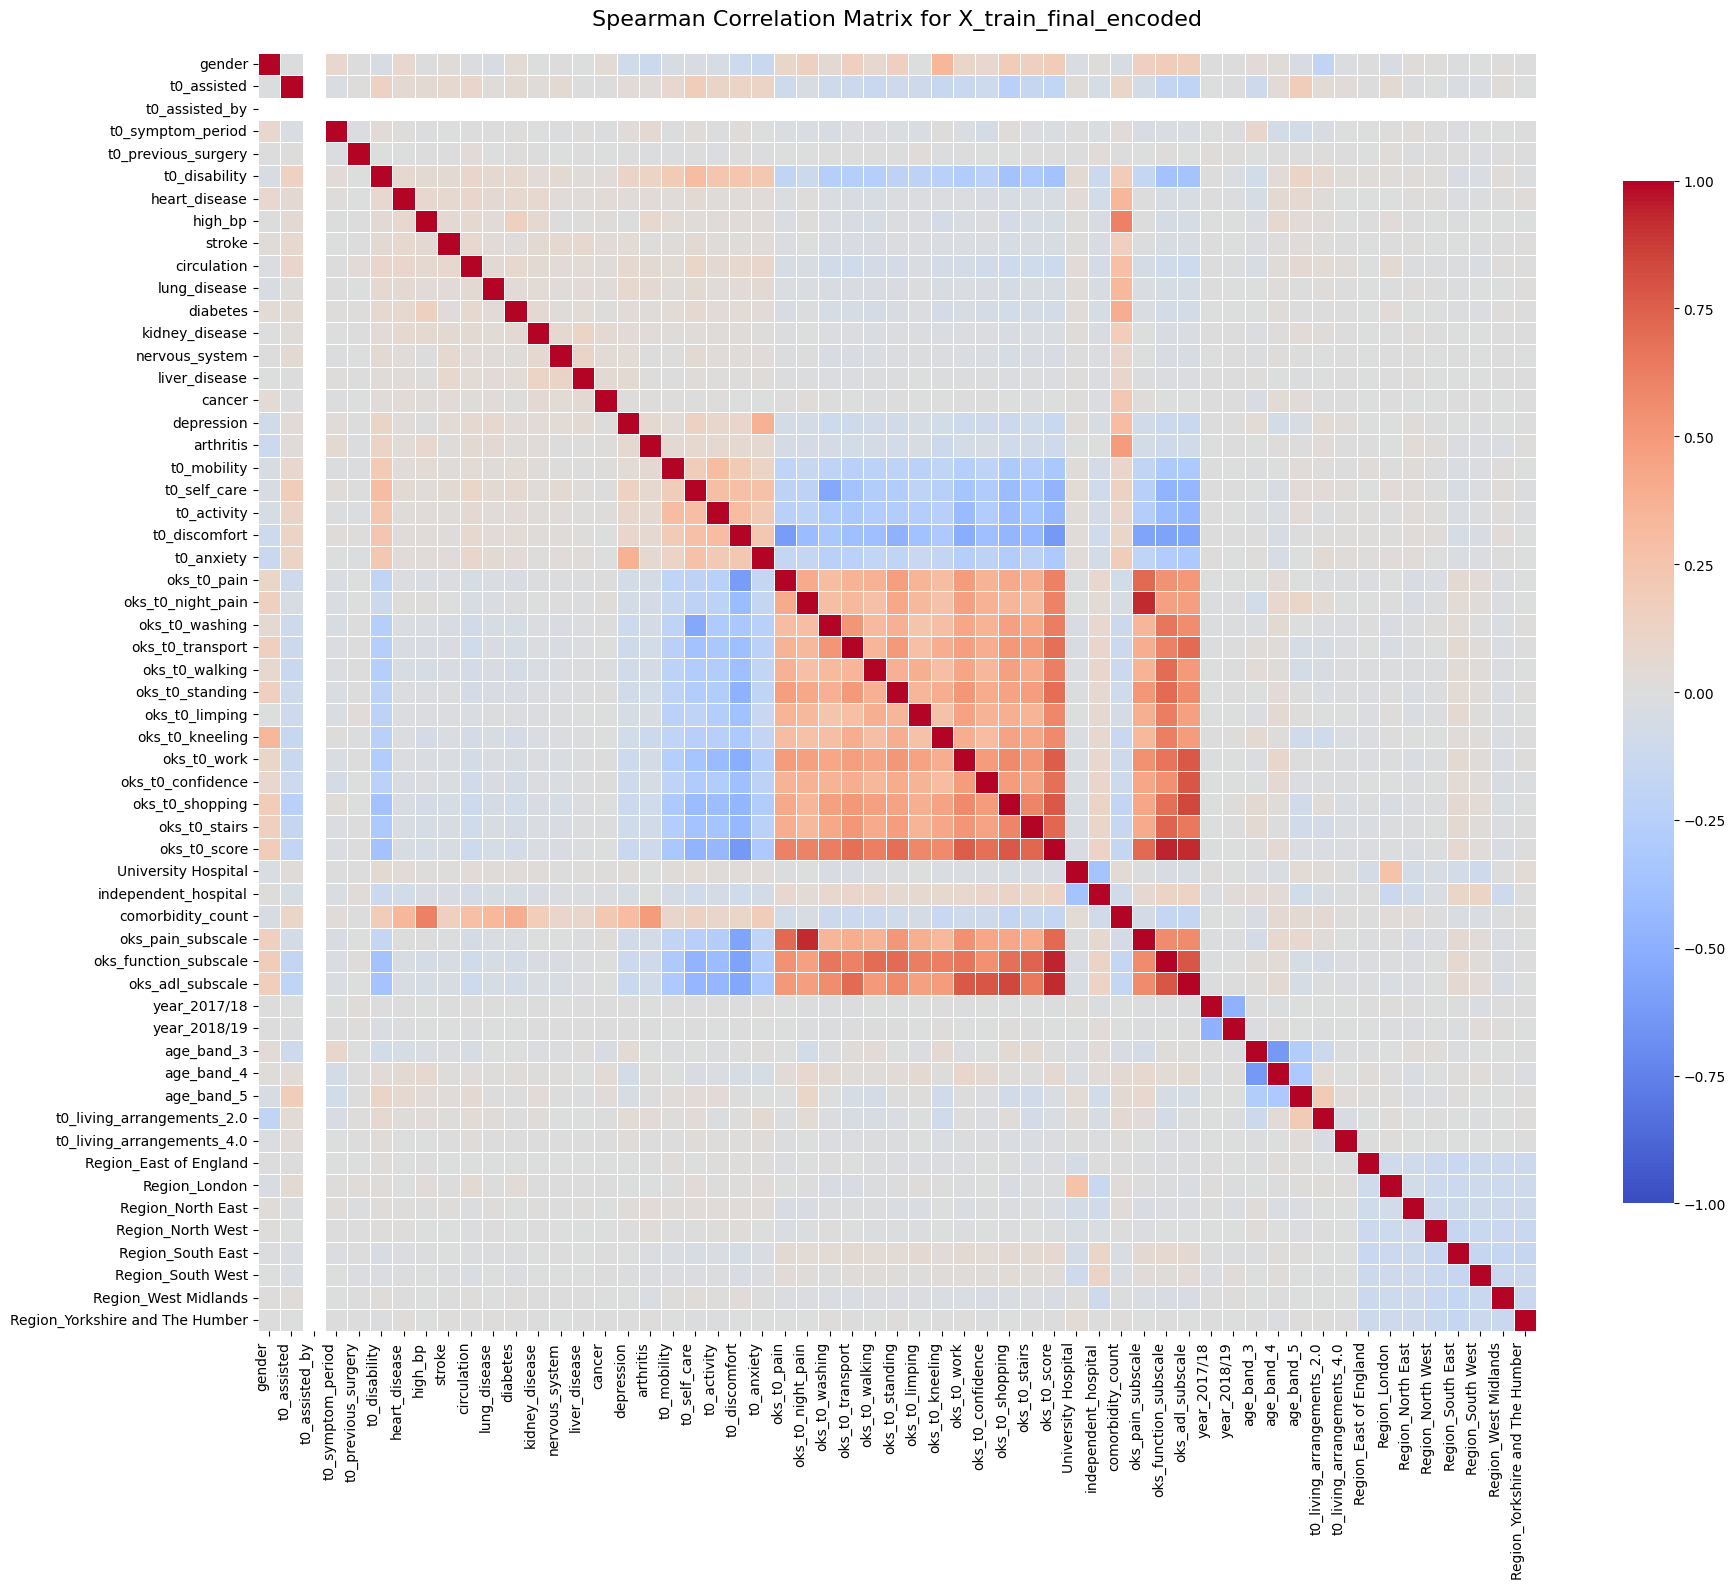


Highly correlated variable pairs (|correlation| > 0.7):
oks_t0_score <-> oks_function_subscale: 0.940
oks_t0_score <-> oks_adl_subscale: 0.924
oks_t0_night_pain <-> oks_pain_subscale: 0.923
oks_t0_shopping <-> oks_adl_subscale: 0.842
oks_function_subscale <-> oks_adl_subscale: 0.787
oks_t0_confidence <-> oks_adl_subscale: 0.785
oks_t0_shopping <-> oks_t0_score: 0.778
oks_t0_work <-> oks_adl_subscale: 0.775
oks_t0_work <-> oks_t0_score: 0.765
oks_t0_stairs <-> oks_function_subscale: 0.742
oks_t0_stairs <-> oks_t0_score: 0.725
oks_t0_pain <-> oks_pain_subscale: 0.714
oks_t0_score <-> oks_pain_subscale: 0.712
oks_t0_transport <-> oks_adl_subscale: 0.706
oks_t0_standing <-> oks_function_subscale: 0.704

Correlation Summary Statistics:
Mean absolute correlation: 0.094
Median absolute correlation: 0.028
Max correlation: 0.940
Min correlation: -0.630
Std of correlations: 0.179


In [22]:
# Correlation Analysis for X_train_final_encoded
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate Spearman correlation (works well with both continuous and binary variables)
correlation_matrix = X_train_final_encoded.corr(method='spearman')

print(f"Correlation matrix shape: {correlation_matrix.shape}")
print(f"\nHighest correlations with each variable (top 5):")
print("=" * 80)

# For each variable, show top 5 correlations (excluding self-correlation)
for col in X_train_final_encoded.columns[:10]:  # Show first 10 variables as example
    correlations = correlation_matrix[col].sort_values(ascending=False)
    # Exclude self-correlation
    top_correlations = correlations[correlations.index != col].head(5)
    print(f"\n{col}:")
    for idx, val in top_correlations.items():
        print(f"  {idx}: {val:.3f}")

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(correlation_matrix, 
            annot=False,  # Set to True if you want to see values (may be cluttered with 45 features)
            cmap='coolwarm', 
            center=0,
            vmin=-1, 
            vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Spearman Correlation Matrix for X_train_final_encoded', fontsize=16, pad=20)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Find highly correlated pairs (|correlation| > 0.7)
print("\n" + "=" * 80)
print("Highly correlated variable pairs (|correlation| > 0.7):")
print("=" * 80)

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'var1': correlation_matrix.columns[i],
                'var2': correlation_matrix.columns[j],
                'correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    for pair in sorted(high_corr_pairs, key=lambda x: abs(x['correlation']), reverse=True):
        print(f"{pair['var1']} <-> {pair['var2']}: {pair['correlation']:.3f}")
else:
    print("No highly correlated pairs found (threshold = 0.7)")

# Summary statistics about correlations
print("\n" + "=" * 80)
print("Correlation Summary Statistics:")
print("=" * 80)
# Get upper triangle of correlation matrix (excluding diagonal)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
upper_triangle = correlation_matrix.where(mask)
all_correlations = upper_triangle.values.flatten()
all_correlations = all_correlations[~np.isnan(all_correlations)]

print(f"Mean absolute correlation: {np.abs(all_correlations).mean():.3f}")
print(f"Median absolute correlation: {np.median(np.abs(all_correlations)):.3f}")
print(f"Max correlation: {all_correlations.max():.3f}")
print(f"Min correlation: {all_correlations.min():.3f}")
print(f"Std of correlations: {all_correlations.std():.3f}")

# Logistic Regression Testing 

RUNNING ALL MODEL CONFIGURATIONS

▶ Training: LR - No weights...
  ✓ Val PR-AUC: 0.3727 | Gap: 0.0017 | Features: 56

▶ Training: LR - Balanced weights...
  ✓ Val PR-AUC: 0.3700 | Gap: 0.0015 | Features: 56

▶ Training: LR - SMOTE...
  ✓ Val PR-AUC: 0.3701 | Gap: 0.0017 | Features: 56

▶ Training: LR - LASSO (L1)...
  ✓ Val PR-AUC: 0.3728 | Gap: 0.0017 | Features: 54

▶ Training: LR - LASSO + Balanced...
  ✓ Val PR-AUC: 0.3701 | Gap: 0.0015 | Features: 54

OVERFITTING ANALYSIS (@ Threshold=0.5)
                       train_precision  val_precision  precision_gap  train_recall  val_recall  recall_gap overfit_flag
LR - No weights                 0.6552         0.6607        -0.0056        0.0800      0.0804     -0.0004         ✓ OK
LR - Balanced weights           0.2895         0.2883         0.0012        0.6061      0.6031      0.0030         ✓ OK
LR - SMOTE                      0.6457         0.6485        -0.0028        0.0808      0.0816     -0.0008         ✓ OK
LR - LASSO (L1)     

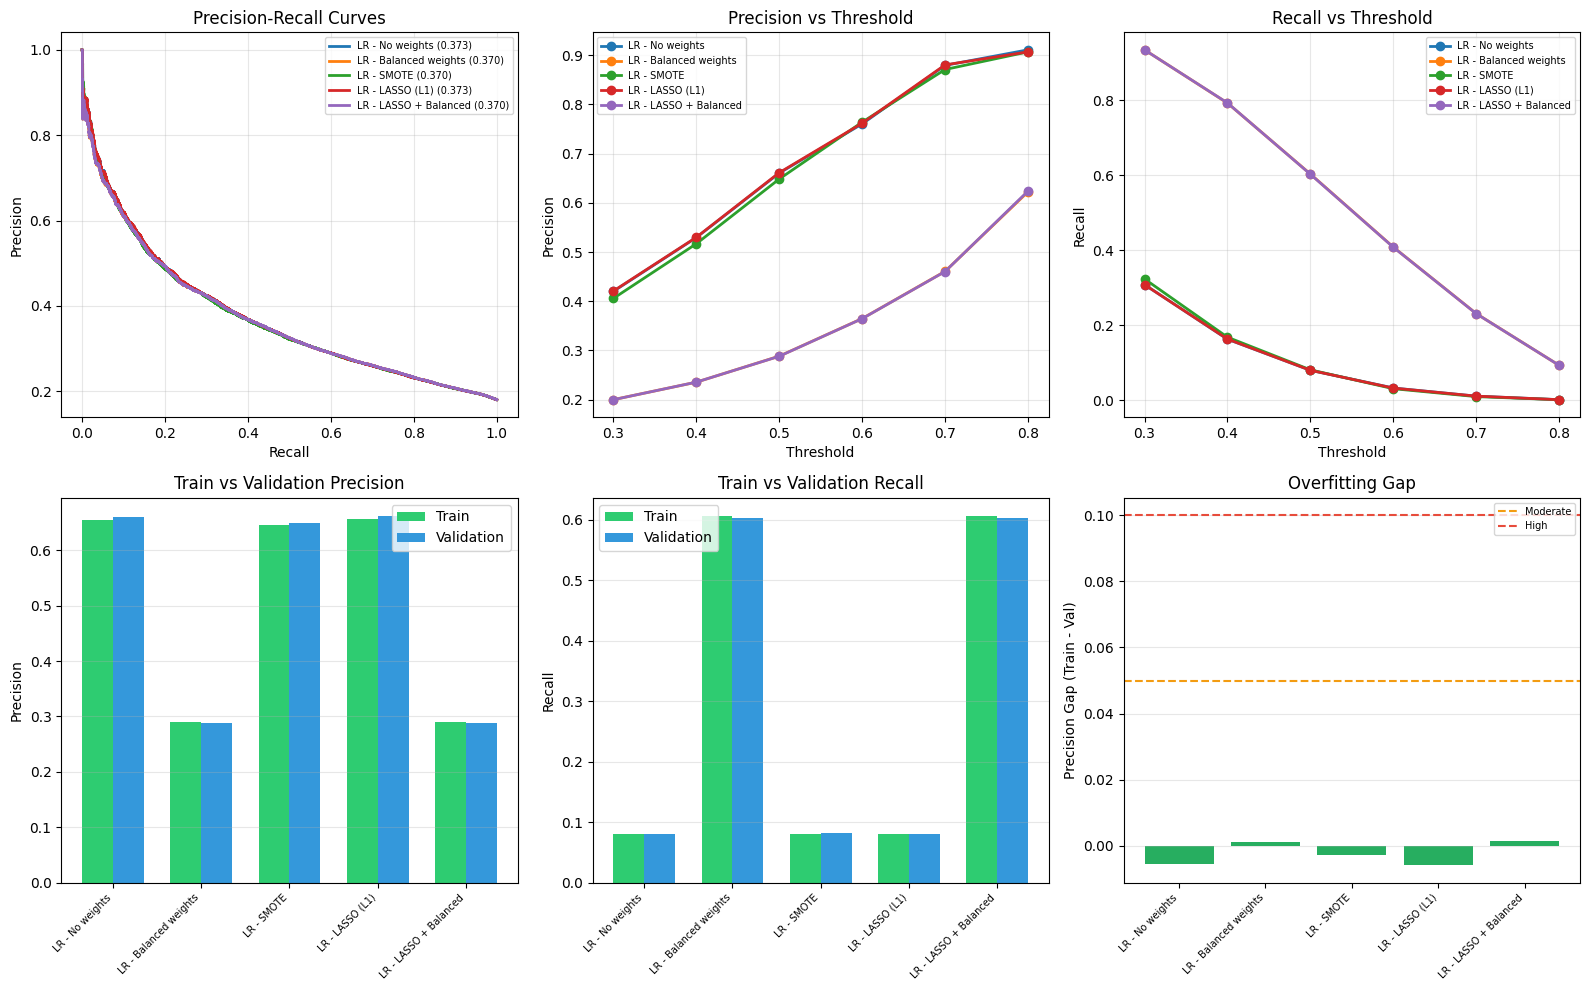

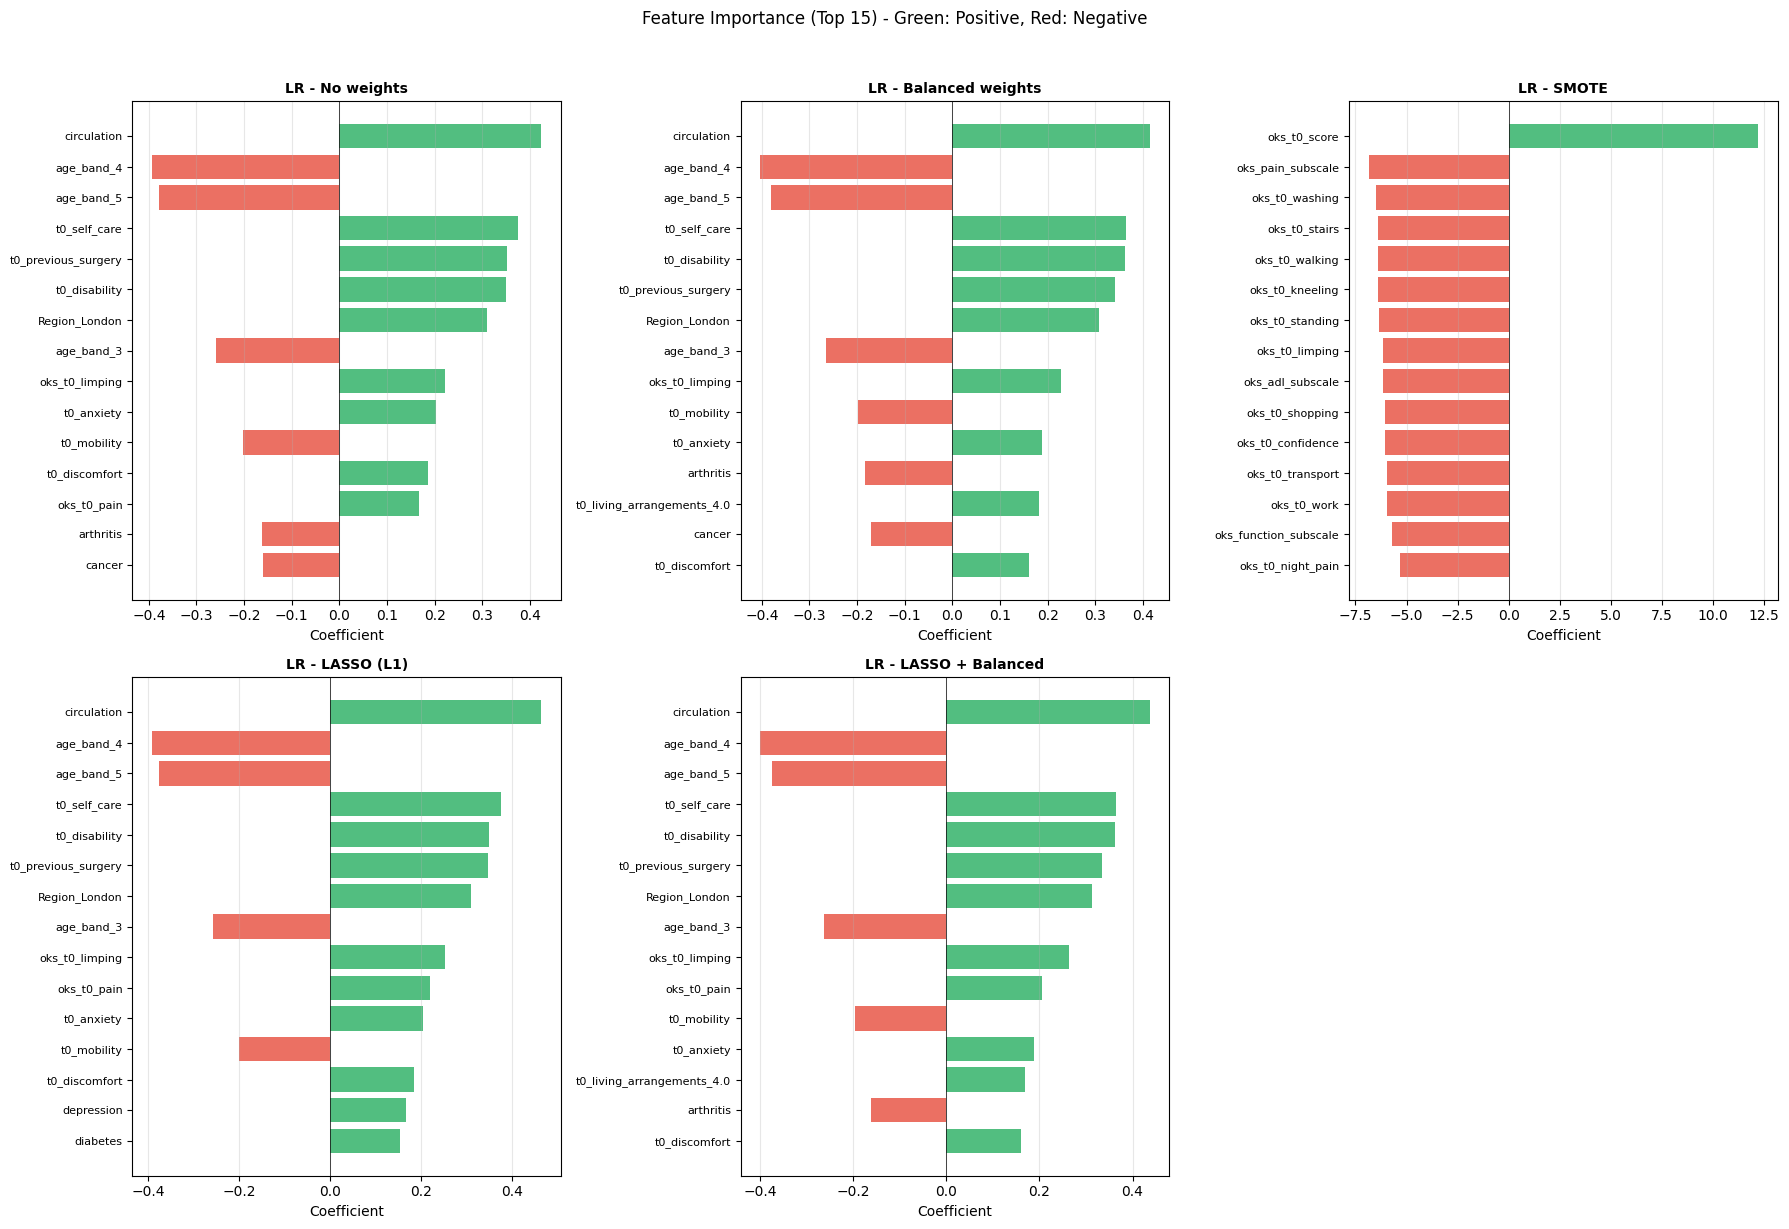


SUMMARY

Best Precision at each threshold:
  0.3: LR - LASSO (L1) → 0.4206
  0.4: LR - LASSO (L1) → 0.5298
  0.5: LR - LASSO (L1) → 0.6612
  0.6: LR - SMOTE → 0.7640
  0.7: LR - LASSO (L1) → 0.8805
  0.8: LR - No weights → 0.9111

Lowest Overfitting Risk:
  LR - LASSO (L1): gap=-0.0059
  LR - No weights: gap=-0.0056
  LR - SMOTE: gap=-0.0028


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc
from sklearn.base import clone
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define model configurations
models = {
    'LR - No weights': LogisticRegression(
        max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1
    ),
    'LR - Balanced weights': LogisticRegression(
        max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1, class_weight='balanced'
    ),
    'LR - SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('lr', LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1))
    ]),
    'LR - LASSO (L1)': LogisticRegression(
        max_iter=1000, random_state=42, solver='saga', penalty='l1', n_jobs=-1
    ),
    'LR - LASSO + Balanced': LogisticRegression(
        max_iter=1000, random_state=42, solver='saga', penalty='l1', n_jobs=-1, class_weight='balanced'
    ),
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

# Store results
results = {}
overfit_results = {}
proba_dict = {}
feature_importance_dict = {}

# Feature names
feature_names = X_train_final_encoded.columns.tolist()

print("=" * 80)
print("RUNNING ALL MODEL CONFIGURATIONS")
print("=" * 80)

for name, model in models.items():
    print(f"\n▶ Training: {name}...")
    
    # Storage for cross-validation
    val_probas = np.zeros(len(y_train))
    train_precisions, val_precisions = [], []
    train_recalls, val_recalls = [], []
    train_pr_aucs, val_pr_aucs = [], []
    fold_coefs = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train_final_encoded, y_train)):
        X_tr, X_val = X_train_final_encoded.iloc[train_idx], X_train_final_encoded.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Clone and fit model
        model_clone = clone(model)
        model_clone.fit(X_tr, y_tr)
        
        # Extract coefficients
        if hasattr(model_clone, 'coef_'):
            fold_coefs.append(model_clone.coef_[0])
        elif hasattr(model_clone, 'named_steps'):
            fold_coefs.append(model_clone.named_steps['lr'].coef_[0])
        
        # Get probabilities
        train_proba = model_clone.predict_proba(X_tr)[:, 1]
        val_proba = model_clone.predict_proba(X_val)[:, 1]
        val_probas[val_idx] = val_proba
        
        # Metrics at threshold=0.5
        train_pred = (train_proba >= 0.5).astype(int)
        val_pred = (val_proba >= 0.5).astype(int)
        
        train_precisions.append(precision_score(y_tr, train_pred, zero_division=0))
        val_precisions.append(precision_score(y_val, val_pred, zero_division=0))
        train_recalls.append(recall_score(y_tr, train_pred, zero_division=0))
        val_recalls.append(recall_score(y_val, val_pred, zero_division=0))
        
        # PR-AUC
        prec_tr, rec_tr, _ = precision_recall_curve(y_tr, train_proba)
        prec_val, rec_val, _ = precision_recall_curve(y_val, val_proba)
        train_pr_aucs.append(auc(rec_tr, prec_tr))
        val_pr_aucs.append(auc(rec_val, prec_val))
    
    proba_dict[name] = val_probas
    
    # Average coefficients across folds
    avg_coefs = np.mean(fold_coefs, axis=0)
    feature_importance_dict[name] = pd.DataFrame({
        'feature': feature_names,
        'coefficient': avg_coefs,
        'abs_importance': np.abs(avg_coefs)
    }).sort_values('abs_importance', ascending=False)
    
    # Store metrics
    overfit_results[name] = {
        'train_precision': np.mean(train_precisions),
        'val_precision': np.mean(val_precisions),
        'precision_gap': np.mean(train_precisions) - np.mean(val_precisions),
        'train_recall': np.mean(train_recalls),
        'val_recall': np.mean(val_recalls),
        'recall_gap': np.mean(train_recalls) - np.mean(val_recalls),
        'train_pr_auc': np.mean(train_pr_aucs),
        'val_pr_auc': np.mean(val_pr_aucs),
        'pr_auc_gap': np.mean(train_pr_aucs) - np.mean(val_pr_aucs),
        'n_nonzero_features': np.sum(np.abs(avg_coefs) > 1e-6)
    }
    
    # Metrics at each threshold
    model_results = []
    for thresh in thresholds:
        y_pred = (val_probas >= thresh).astype(int)
        model_results.append({
            'threshold': thresh,
            'precision': precision_score(y_train, y_pred, zero_division=0),
            'recall': recall_score(y_train, y_pred, zero_division=0),
            'f1': f1_score(y_train, y_pred, zero_division=0),
            'n_predicted_pos': y_pred.sum()
        })
    
    results[name] = pd.DataFrame(model_results)
    print(f"  ✓ Val PR-AUC: {overfit_results[name]['val_pr_auc']:.4f} | Gap: {overfit_results[name]['pr_auc_gap']:.4f} | Features: {overfit_results[name]['n_nonzero_features']}")

# === OVERFITTING TABLE ===
print("\n" + "=" * 80)
print("OVERFITTING ANALYSIS (@ Threshold=0.5)")
print("=" * 80)

overfit_df = pd.DataFrame(overfit_results).T
overfit_df['overfit_flag'] = overfit_df['precision_gap'].apply(
    lambda x: '⚠️ HIGH' if x > 0.1 else ('⚡ MOD' if x > 0.05 else '✓ OK')
)
print(overfit_df[['train_precision', 'val_precision', 'precision_gap', 
                   'train_recall', 'val_recall', 'recall_gap', 'overfit_flag']].round(4).to_string())

# === THRESHOLD TABLES ===
print("\n" + "=" * 80)
print("VALIDATION PRECISION ACROSS THRESHOLDS")
print("=" * 80)

comparison_df = pd.DataFrame()
for name, df in results.items():
    comparison_df[name] = df.set_index('threshold')['precision']
print(comparison_df.round(4).to_string())

print("\n" + "=" * 80)
print("VALIDATION RECALL ACROSS THRESHOLDS")
print("=" * 80)

recall_df = pd.DataFrame()
for name, df in results.items():
    recall_df[name] = df.set_index('threshold')['recall']
print(recall_df.round(4).to_string())

# === FEATURE IMPORTANCE FOR EACH MODEL ===
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE (TOP 15 PER MODEL)")
print("=" * 80)

for name, fi_df in feature_importance_dict.items():
    print(f"\n{'─' * 60}")
    print(f"📊 {name}")
    print(f"{'─' * 60}")
    top_15 = fi_df.head(15).reset_index(drop=True)
    top_15.index = top_15.index + 1  # Start from 1
    print(top_15[['feature', 'coefficient', 'abs_importance']].to_string())
    
    if 'LASSO' in name:
        n_zero = (fi_df['abs_importance'] < 1e-6).sum()
        n_kept = len(fi_df) - n_zero
        print(f"\n  → LASSO kept {n_kept}/{len(fi_df)} features (eliminated {n_zero})")

# === PLOTS ===
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: PR Curves
ax1 = axes[0, 0]
for name, y_proba in proba_dict.items():
    prec_curve, rec_curve, _ = precision_recall_curve(y_train, y_proba)
    pr_auc = auc(rec_curve, prec_curve)
    ax1.plot(rec_curve, prec_curve, label=f'{name} ({pr_auc:.3f})', linewidth=2)
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curves')
ax1.legend(loc='best', fontsize=7)
ax1.grid(True, alpha=0.3)

# Plot 2: Precision vs Threshold
ax2 = axes[0, 1]
for name, df in results.items():
    ax2.plot(df['threshold'], df['precision'], marker='o', label=name, linewidth=2)
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Precision')
ax2.set_title('Precision vs Threshold')
ax2.legend(loc='best', fontsize=7)
ax2.grid(True, alpha=0.3)

# Plot 3: Recall vs Threshold
ax3 = axes[0, 2]
for name, df in results.items():
    ax3.plot(df['threshold'], df['recall'], marker='o', label=name, linewidth=2)
ax3.set_xlabel('Threshold')
ax3.set_ylabel('Recall')
ax3.set_title('Recall vs Threshold')
ax3.legend(loc='best', fontsize=7)
ax3.grid(True, alpha=0.3)

# Plot 4: Train vs Val Precision
ax4 = axes[1, 0]
x_pos = np.arange(len(overfit_results))
width = 0.35
train_prec = [v['train_precision'] for v in overfit_results.values()]
val_prec = [v['val_precision'] for v in overfit_results.values()]
ax4.bar(x_pos - width/2, train_prec, width, label='Train', color='#2ecc71')
ax4.bar(x_pos + width/2, val_prec, width, label='Validation', color='#3498db')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(list(overfit_results.keys()), rotation=45, ha='right', fontsize=7)
ax4.set_ylabel('Precision')
ax4.set_title('Train vs Validation Precision')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Train vs Val Recall
ax5 = axes[1, 1]
train_rec = [v['train_recall'] for v in overfit_results.values()]
val_rec = [v['val_recall'] for v in overfit_results.values()]
ax5.bar(x_pos - width/2, train_rec, width, label='Train', color='#2ecc71')
ax5.bar(x_pos + width/2, val_rec, width, label='Validation', color='#3498db')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(list(overfit_results.keys()), rotation=45, ha='right', fontsize=7)
ax5.set_ylabel('Recall')
ax5.set_title('Train vs Validation Recall')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Overfitting Gap
ax6 = axes[1, 2]
gaps = [v['precision_gap'] for v in overfit_results.values()]
colors = ['#e74c3c' if g > 0.1 else '#f39c12' if g > 0.05 else '#27ae60' for g in gaps]
ax6.bar(x_pos, gaps, color=colors)
ax6.axhline(y=0.05, color='#f39c12', linestyle='--', label='Moderate')
ax6.axhline(y=0.1, color='#e74c3c', linestyle='--', label='High')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(list(overfit_results.keys()), rotation=45, ha='right', fontsize=7)
ax6.set_ylabel('Precision Gap (Train - Val)')
ax6.set_title('Overfitting Gap')
ax6.legend(fontsize=7)
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

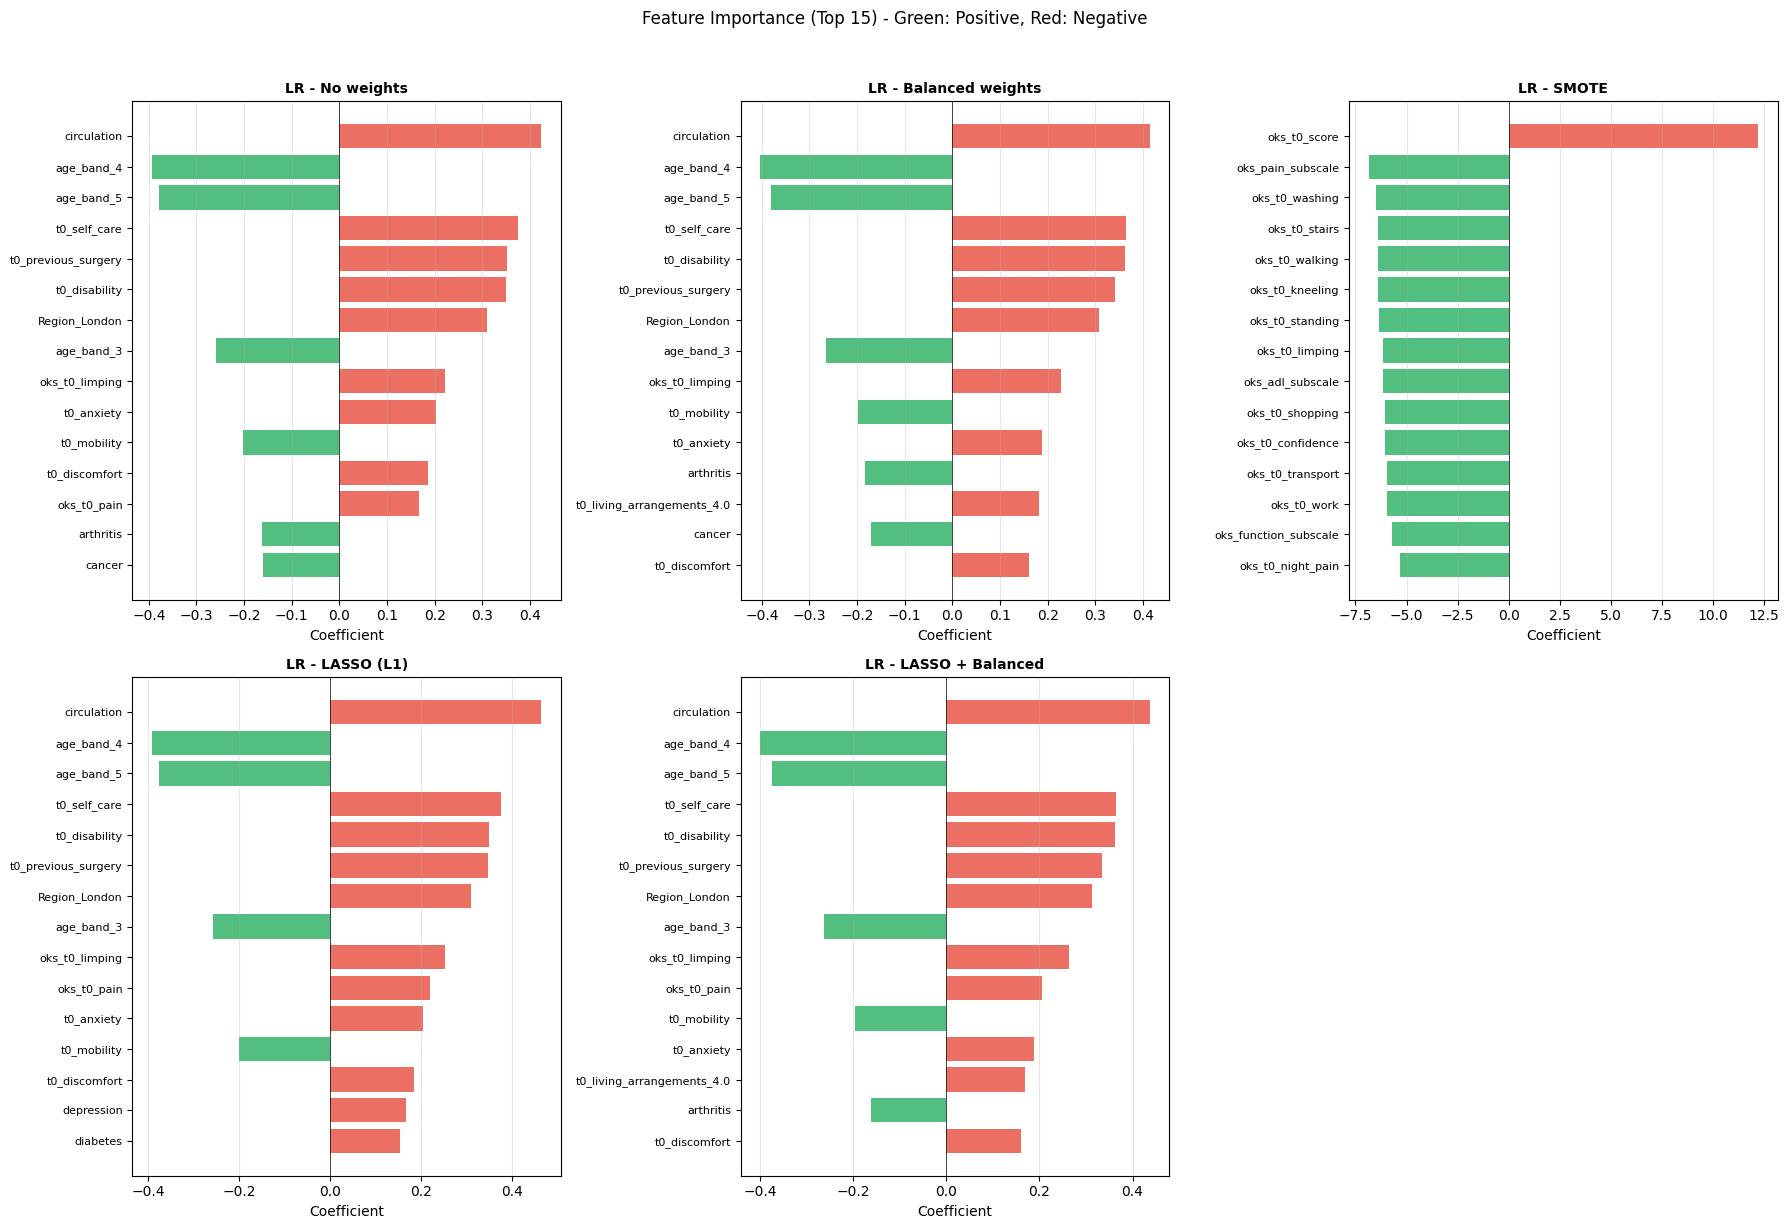


SUMMARY

Best Precision at each threshold:
  0.3: LR - LASSO (L1) → 0.4206
  0.4: LR - LASSO (L1) → 0.5298
  0.5: LR - LASSO (L1) → 0.6612
  0.6: LR - SMOTE → 0.7640
  0.7: LR - LASSO (L1) → 0.8805
  0.8: LR - No weights → 0.9111

Lowest Overfitting Risk:
  LR - LASSO (L1): gap=-0.0059
  LR - No weights: gap=-0.0056
  LR - SMOTE: gap=-0.0028


In [25]:
# === FEATURE IMPORTANCE PLOTS ===
n_models = len(feature_importance_dict)
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 12))
axes2 = axes2.flatten()

for idx, (name, fi_df) in enumerate(feature_importance_dict.items()):
    ax = axes2[idx]
    top_15 = fi_df.head(15)
    colors = ['#27ae60' if c < 0 else '#e74c3c' for c in top_15['coefficient']]
    y_pos = np.arange(len(top_15))
    ax.barh(y_pos, top_15['coefficient'], color=colors, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_15['feature'], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Coefficient')
    ax.set_title(f'{name}', fontsize=10, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='x')

axes2[5].axis('off')  # Hide empty subplot
plt.suptitle('Feature Importance (Top 15) - Green: Positive, Red: Negative', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# === SUMMARY ===
print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)

print("\nBest Precision at each threshold:")
for thresh in thresholds:
    best_model = comparison_df.loc[thresh].idxmax()
    best_prec = comparison_df.loc[thresh].max()
    print(f"  {thresh}: {best_model} → {best_prec:.4f}")

print("\nLowest Overfitting Risk:")
sorted_by_gap = sorted(overfit_results.items(), key=lambda x: x[1]['precision_gap'])
for name, m in sorted_by_gap[:3]:
    print(f"  {name}: gap={m['precision_gap']:.4f}")


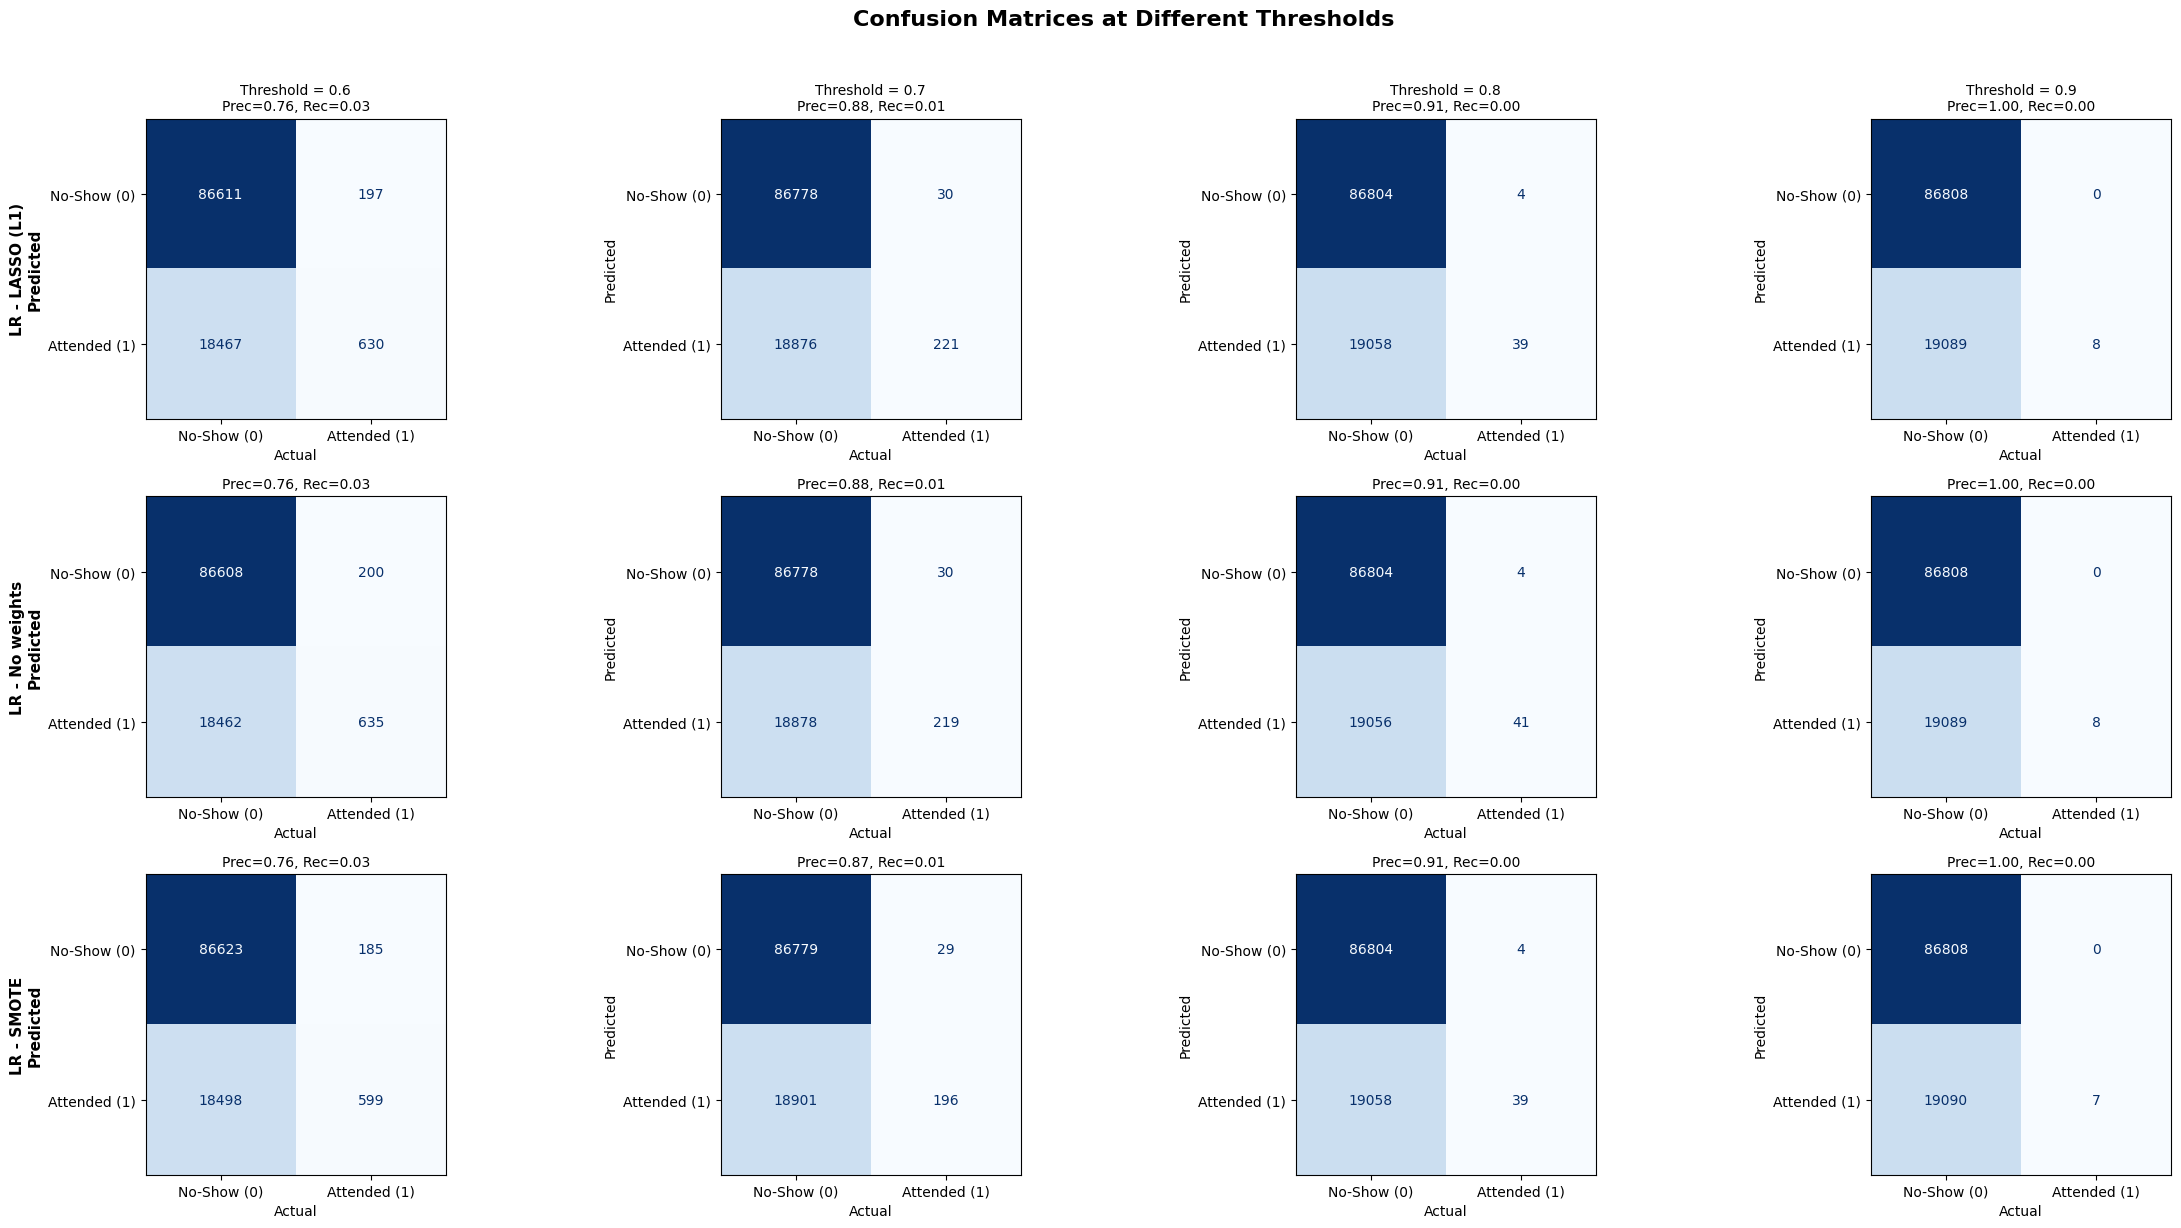


SUMMARY: Confusion Matrix Metrics at Different Thresholds

📊 LR - LASSO (L1)
----------------------------------------------------------------------
Threshold          TN       FP       FN       TP  Precision     Recall  Specificity
----------------------------------------------------------------------
0.6            86,611      197   18,467      630     0.7618     0.0330       0.9977
0.7            86,778       30   18,876      221     0.8805     0.0116       0.9997
0.8            86,804        4   19,058       39     0.9070     0.0020       1.0000
0.9            86,808        0   19,089        8     1.0000     0.0004       1.0000

📊 LR - No weights
----------------------------------------------------------------------
Threshold          TN       FP       FN       TP  Precision     Recall  Specificity
----------------------------------------------------------------------
0.6            86,608      200   18,462      635     0.7605     0.0333       0.9977
0.7            86,778       30 

In [32]:
# Create confusion matrix at different thresholds for the these models: LR - LASSO (L1), LR - No weights, LR - SMOTE

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Models to analyze
selected_models = ['LR - LASSO (L1)', 'LR - No weights', 'LR - SMOTE']

# Thresholds to evaluate
thresholds = [0.6, 0.7, 0.8, 0.9]

# Create figure with subplots: rows = models, columns = thresholds
fig, axes = plt.subplots(len(selected_models), len(thresholds), figsize=(24, 12))
fig.suptitle('Confusion Matrices at Different Thresholds', fontsize=16, fontweight='bold', y=1.02)

for row, model_name in enumerate(selected_models):
    if model_name not in proba_dict:
        print(f"Warning: {model_name} not found in proba_dict")
        continue
    
    probas = proba_dict[model_name]
    
    for col, thresh in enumerate(thresholds):
        # Convert probabilities to predictions at this threshold
        y_pred = (probas >= thresh).astype(int)
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_train, y_pred)
        
        # Plot confusion matrix
        ax = axes[row, col]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No-Show (0)', 'Attended (1)'])
        disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
        
        # Calculate metrics for title
        tn, fp, fn, tp = cm.ravel()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        if row == 0:
            ax.set_title(f'Threshold = {thresh}\nPrec={precision:.2f}, Rec={recall:.2f}', fontsize=10)
        else:
            ax.set_title(f'Prec={precision:.2f}, Rec={recall:.2f}', fontsize=10)
        
        if col == 0:
            ax.set_ylabel(f'{model_name}\nPredicted', fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel('Predicted')
        
        ax.set_xlabel('Actual')

plt.tight_layout()
#plt.savefig('../outputs/confusion_matrices_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("SUMMARY: Confusion Matrix Metrics at Different Thresholds")
print("="*80)

# Print summary table
for model_name in selected_models:
    if model_name not in proba_dict:
        continue
    
    print(f"\n📊 {model_name}")
    print("-" * 70)
    print(f"{'Threshold':<12} {'TN':>8} {'FP':>8} {'FN':>8} {'TP':>8} {'Precision':>10} {'Recall':>10} {'Specificity':>12}")
    print("-" * 70)
    
    probas = proba_dict[model_name]
    
    for thresh in thresholds:
        y_pred = (probas >= thresh).astype(int)
        cm = confusion_matrix(y_train, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        print(f"{thresh:<12.1f} {tn:>8,} {fp:>8,} {fn:>8,} {tp:>8,} {precision:>10.4f} {recall:>10.4f} {specificity:>12.4f}")


# Random Forest

RANDOM FOREST WITH HYPERPARAMETER TUNING

📋 STEP 1: DEFINING HYPERPARAMETER SEARCH SPACE
--------------------------------------------------
Hyperparameters to tune:
  • n_estimators: [100, 200]
  • max_depth: [10, 15, 20]
  • min_samples_split: [5, 10]
  • min_samples_leaf: [2, 4]
  • class_weight: ['balanced', None]

Total combinations: 48

📋 STEP 2: RUNNING GRID SEARCH (5-Fold CV)
--------------------------------------------------
Starting grid search... (this may take a few minutes)
Fitting 5 folds for each of 48 candidates, totalling 240 fits

✓ Grid search complete!

Best Parameters:
  • class_weight: None
  • max_depth: 15
  • min_samples_leaf: 4
  • min_samples_split: 10
  • n_estimators: 200

Best CV ROC-AUC Score: 0.6911

📋 STEP 3: GETTING CROSS-VALIDATED PREDICTIONS
--------------------------------------------------
✓ Generated 105,905 probability predictions via 5-fold CV

📋 STEP 4: CONFUSION MATRICES AT THRESHOLDS > 0.5
--------------------------------------------------


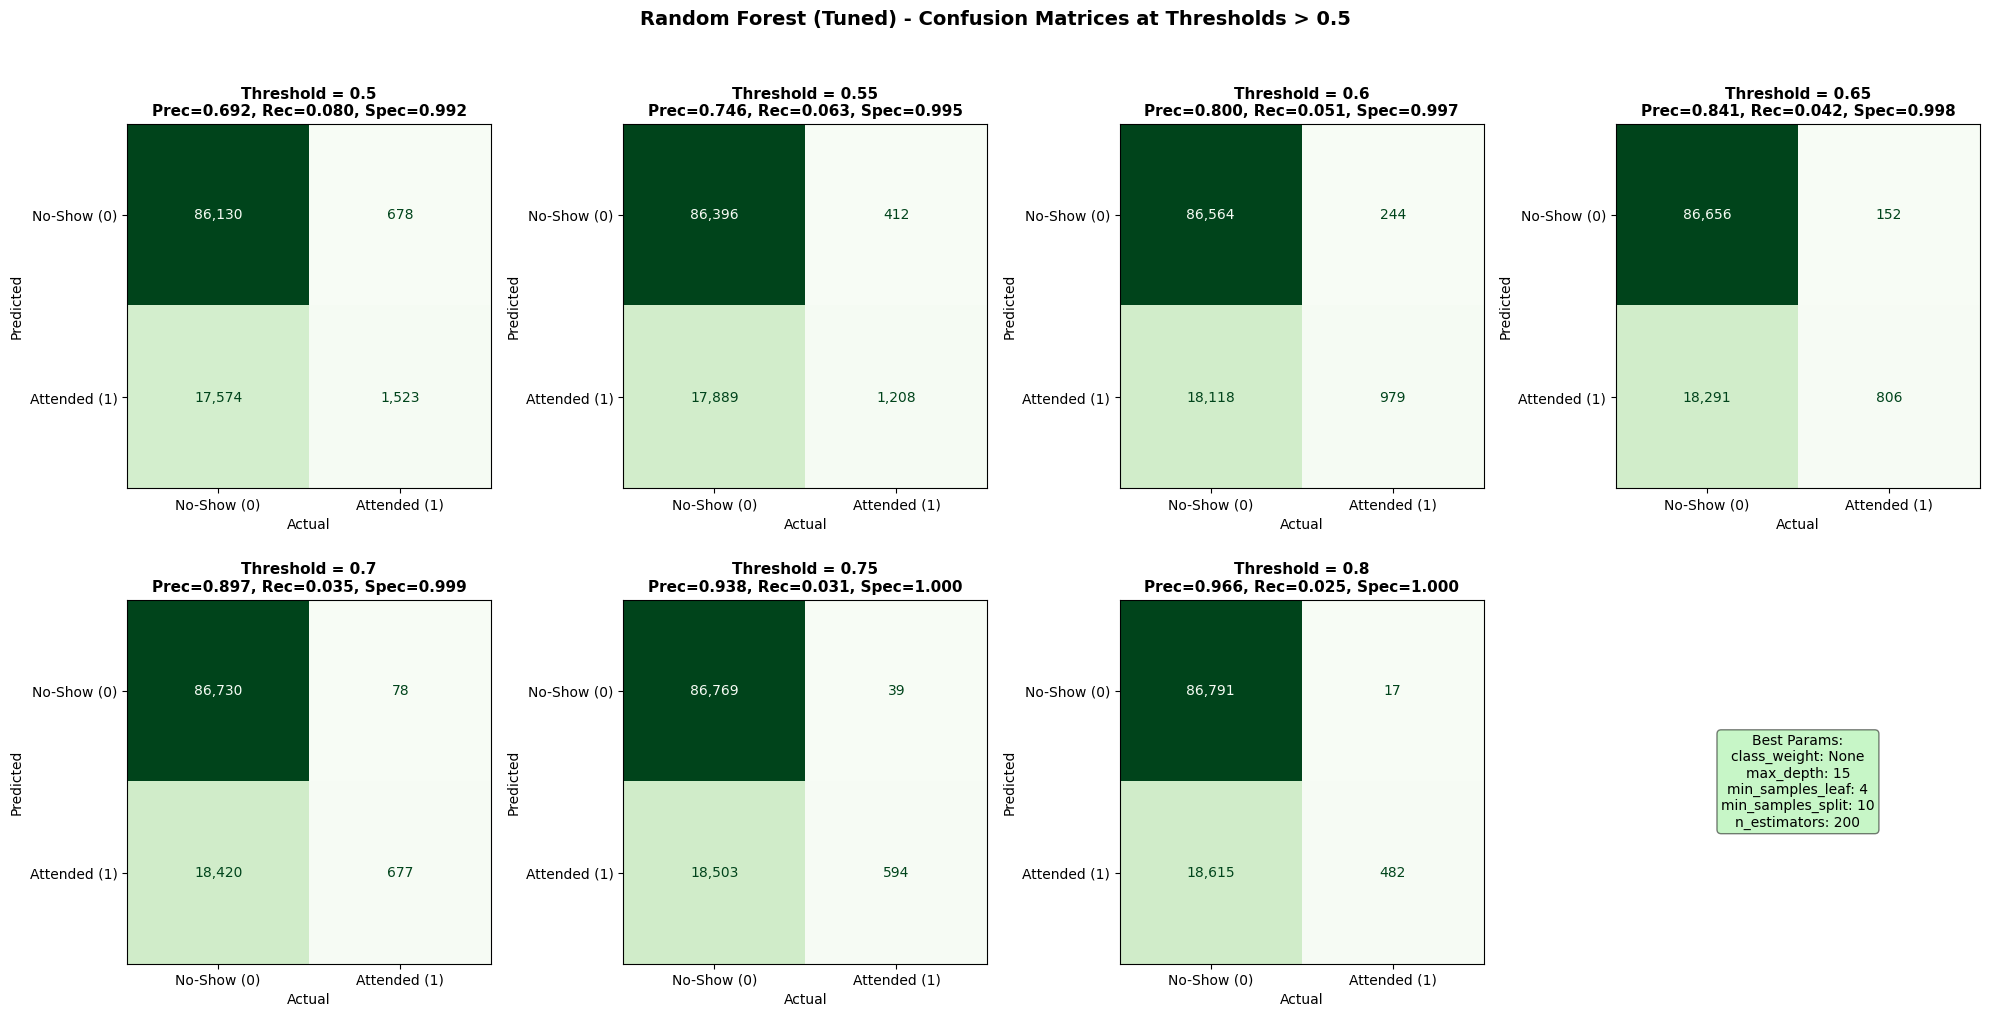


📋 STEP 5: METRICS SUMMARY

 Threshold    TN  FP    FN   TP  Precision   Recall  Specificity       F1
      0.50 86130 678 17574 1523   0.691958 0.079751     0.992190 0.143018
      0.55 86396 412 17889 1208   0.745679 0.063256     0.995254 0.116619
      0.60 86564 244 18118  979   0.800491 0.051265     0.997189 0.096358
      0.65 86656 152 18291  806   0.841336 0.042206     0.998249 0.080379
      0.70 86730  78 18420  677   0.896689 0.035451     0.999101 0.068205
      0.75 86769  39 18503  594   0.938389 0.031104     0.999551 0.060213
      0.80 86791  17 18615  482   0.965932 0.025240     0.999804 0.049194

📋 STEP 6: TOP 15 FEATURE IMPORTANCES
--------------------------------------------------
              Feature  Importance
         oks_t0_score    0.110534
oks_function_subscale    0.101480
       oks_t0_limping    0.077731
     oks_adl_subscale    0.058900
          oks_t0_pain    0.033760
    oks_pain_subscale    0.033394
          oks_t0_work    0.030736
    comorbidity_cou

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/rf_tuned_feature_importance.png'

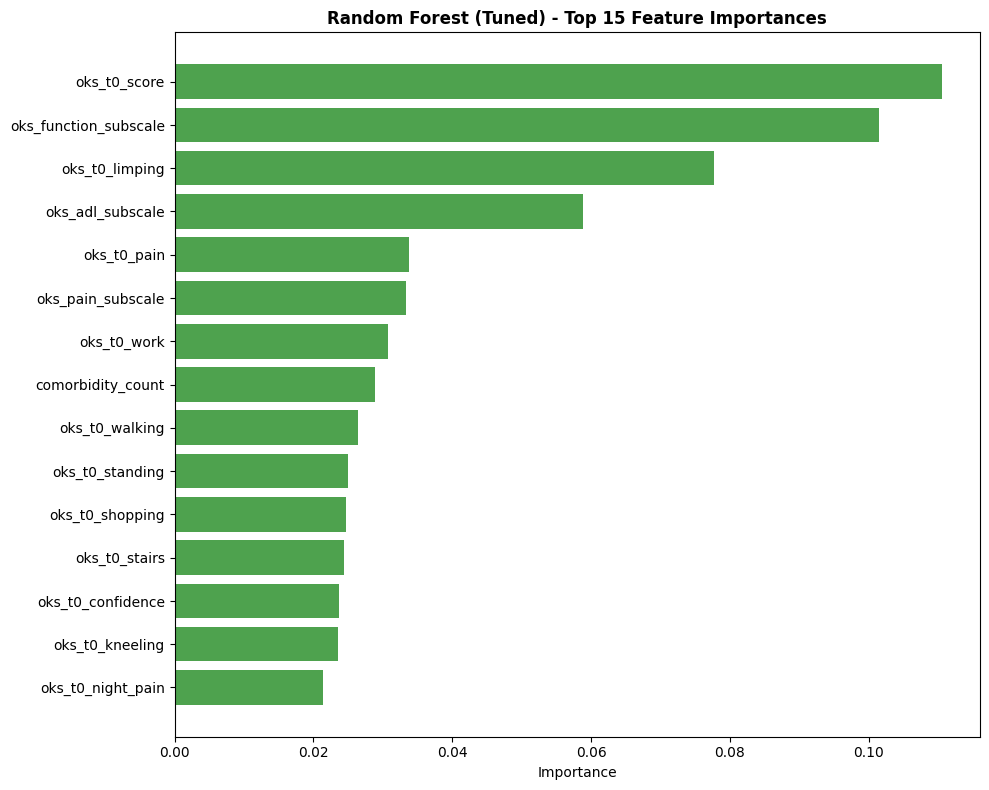

In [ ]:
# =============================================================================
# RANDOM FOREST WITH HYPERPARAMETER TUNING + CONFUSION MATRICES AT THRESHOLDS > 0.5
# =============================================================================

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_predict, StratifiedKFold
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, 
                             precision_score, recall_score, f1_score, 
                             roc_auc_score, average_precision_score,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("RANDOM FOREST WITH HYPERPARAMETER TUNING")
print("="*80)

# -----------------------------------------------------------------------------
# STEP 1: DEFINE HYPERPARAMETER GRID
# -----------------------------------------------------------------------------
print("\n📋 STEP 1: DEFINING HYPERPARAMETER SEARCH SPACE")
print("-" * 50)

param_grid = {
    'n_estimators': [100, 200],           # Number of trees
    'max_depth': [10, 15, 20],            # Maximum depth of trees
    'min_samples_split': [5, 10],         # Min samples to split a node
    'min_samples_leaf': [2, 4],           # Min samples at leaf node
    'class_weight': ['balanced', None],   # Handle class imbalance
}

print("Hyperparameters to tune:")
for param, values in param_grid.items():
    print(f"  • {param}: {values}")

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\nTotal combinations: {total_combinations}")

# -----------------------------------------------------------------------------
# STEP 2: PERFORM GRID SEARCH WITH CROSS-VALIDATION
# -----------------------------------------------------------------------------
print("\n📋 STEP 2: RUNNING GRID SEARCH (5-Fold CV)")
print("-" * 50)

# Base Random Forest
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Setup cross-validation
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search - using ROC-AUC as scoring metric
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=cv_inner,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Starting grid search... (this may take a few minutes)")
grid_search.fit(X_train_final_encoded, y_train)

print("\n✓ Grid search complete!")
print(f"\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  • {param}: {value}")
print(f"\nBest CV ROC-AUC Score: {grid_search.best_score_:.4f}")

# -----------------------------------------------------------------------------
# STEP 3: GET CROSS-VALIDATED PREDICTIONS WITH BEST MODEL
# -----------------------------------------------------------------------------
print("\n📋 STEP 3: GETTING CROSS-VALIDATED PREDICTIONS")
print("-" * 50)

# Create the best model
best_rf = grid_search.best_estimator_

# Get cross-validated probability predictions
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_probas = cross_val_predict(best_rf, X_train_final_encoded, y_train, cv=cv_outer, method='predict_proba')[:, 1]

print(f"✓ Generated {len(rf_probas):,} probability predictions via 5-fold CV")

In [ ]:
# -----------------------------------------------------------------------------
# STEP 4: EVALUATE AT DIFFERENT THRESHOLDS (> 0.5)
# -----------------------------------------------------------------------------
print("\n📋 STEP 4: CONFUSION MATRICES AT THRESHOLDS > 0.5")
print("-" * 50)

thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]

# Create figure for confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Store metrics for summary
metrics_summary = []

for idx, thresh in enumerate(thresholds):
    # Convert probabilities to predictions
    y_pred = (rf_probas >= thresh).astype(int)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_train, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    metrics_summary.append({
        'Threshold': thresh,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1': f1
    })
    
    # Plot confusion matrix
    ax = axes[idx]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No-Show (0)', 'Attended (1)'])
    disp.plot(ax=ax, cmap='Greens', colorbar=False, values_format=',d')
    ax.set_title(f'Threshold = {thresh}\nPrec={precision:.3f}, Rec={recall:.3f}, Spec={specificity:.3f}', 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

# Hide the last empty subplot
axes[-1].axis('off')
axes[-1].text(0.5, 0.5, f'Best Params:\n' + '\n'.join([f'{k}: {v}' for k, v in grid_search.best_params_.items()]),
              ha='center', va='center', fontsize=10, transform=axes[-1].transAxes,
              bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

fig.suptitle('Random Forest (Tuned) - Confusion Matrices at Thresholds > 0.5', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('../outputs/rf_tuned_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------------
# STEP 5: SUMMARY TABLE
# -----------------------------------------------------------------------------
print("\n📋 STEP 5: METRICS SUMMARY")
print("="*80)

metrics_df = pd.DataFrame(metrics_summary)
print("\n" + metrics_df.to_string(index=False))

              Feature  Importance
         oks_t0_score    0.110534
oks_function_subscale    0.101480
       oks_t0_limping    0.077731
     oks_adl_subscale    0.058900
          oks_t0_pain    0.033760
    oks_pain_subscale    0.033394
          oks_t0_work    0.030736
    comorbidity_count    0.028925
       oks_t0_walking    0.026395
      oks_t0_standing    0.024918
      oks_t0_shopping    0.024710
        oks_t0_stairs    0.024348
    oks_t0_confidence    0.023664
      oks_t0_kneeling    0.023603
    oks_t0_night_pain    0.021423


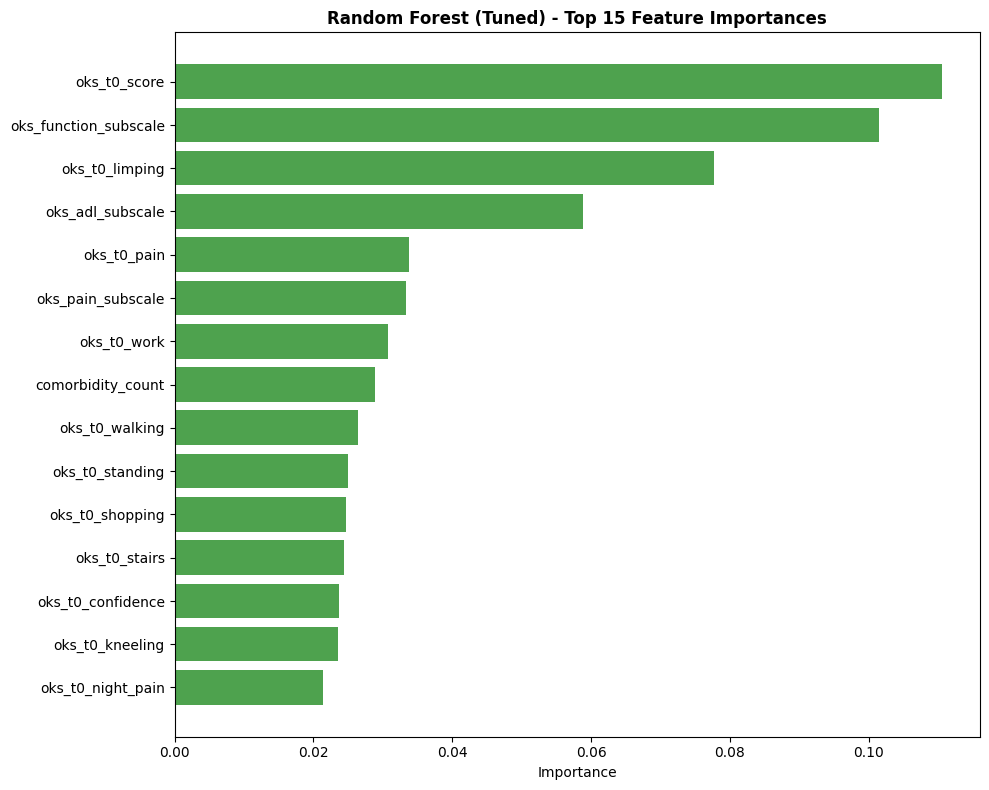


📋 STEP 7: TOP 5 HYPERPARAMETER COMBINATIONS
--------------------------------------------------
                                                                                                  Parameters  Mean CV Score  Std CV Score  Mean Train Score
{'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}       0.691076      0.004498          0.842785
 {'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 200}       0.690992      0.004597          0.846733
{'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}       0.690555      0.004780          0.849668
 {'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}       0.690368      0.003912          0.868092
{'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}       0.689993 

In [ ]:
best_rf.fit(X_train_final_encoded, y_train)

feature_importance = pd.DataFrame({
    'Feature': X_train_final_encoded.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(15).to_string(index=False))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
top_15 = feature_importance.head(15)
bars = ax.barh(range(len(top_15)), top_15['Importance'], color='forestgreen', alpha=0.8)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Random Forest (Tuned) - Top 15 Feature Importances', fontweight='bold')
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# STEP 7: GRID SEARCH RESULTS SUMMARY
# -----------------------------------------------------------------------------
print("\n📋 STEP 7: TOP 5 HYPERPARAMETER COMBINATIONS")
print("-" * 50)

cv_results_df = pd.DataFrame(grid_search.cv_results_)
top_5 = cv_results_df.nsmallest(5, 'rank_test_score')[['params', 'mean_test_score', 'std_test_score', 'mean_train_score']]
top_5.columns = ['Parameters', 'Mean CV Score', 'Std CV Score', 'Mean Train Score']
print(top_5.to_string(index=False))

print("\n" + "="*80)
print("✓ RANDOM FOREST HYPERPARAMETER TUNING COMPLETE")
print("="*80)